# Rolling Indian Ocean SST and IOD forecast

One ECMWF S2S issuance in; western and eastern pole temperatures, the dipole,
and calibrated SST maps out, at five lead horizons — next 30 days and weeks 1–4.

The method follows Funk's steer directly: **simple regression against NOAA OI
values** rather than quantile matching, "particularly appropriate given climate
change", with the **west and east boxes calibrated separately** and combined
afterwards. For a fixed calendar init, each climatology is just the 20-year mean
of that window, so the dipole is reported against **both** a model climatology
and an observed one.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import africas2s as a2s
from africas2s.indices import REGIONS
import iod_pipeline as iod

INIT = "2026-08-31"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.titlesize": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

WLAB = {"week1": "Week 1", "week2": "Week 2", "week3": "Week 3",
        "week4": "Week 4", "day1_30": "Days 1–30"}
POLE_C = {"wio": "#c4552f", "eio": "#1f6f80"}


def _panel_finish(ax, title):
    ax.set_title(title, fontsize=9, pad=6)
    ax.set_xticks([]); ax.set_yticks([])

## The run

`iod_pipeline.run` fetches the live forecast (100 members × 46 leads) and the
20-year on-the-fly reforecast suite keyed to the same calendar day, reduces both
to the five lead windows, pulls the OISST that verified those same windows
historically, and fits an OLS per window and pole.

In [2]:
res = iod.run(INIT, verbose=False)
years = res["years"]
print(f"init {res['init']}   reforecast years {years[0]}–{years[-1]} (n={len(years)})")
print(f"windows: {', '.join(iod.WINDOWS)}")
for w in iod.WINDOWS:
    a, b = iod.window_valid_dates(INIT, w)
    print(f"  {WLAB[w]:10s} verifies {a.date()} → {b.date()}")

init 2026-08-31   reforecast years 2006–2025 (n=20)
windows: week1, week2, week3, week4, day1_30
  Week 1     verifies 2026-08-31 → 2026-09-06
  Week 2     verifies 2026-09-07 → 2026-09-13
  Week 3     verifies 2026-09-14 → 2026-09-20
  Week 4     verifies 2026-09-21 → 2026-09-27
  Days 1–30  verifies 2026-08-31 → 2026-09-29


## The two poles, as separate results

Both in absolute °C, which is what makes the deck's ~29 °C western-pole
threshold directly readable. `slope` is the regression's correction: above 1
means the model under-disperses that pole and the fit stretches it.

In [3]:
for pole in iod.POLES:
    t = res["poles"][pole]
    show = t[["raw", "calibrated", "obs_clim", "slope", "fit_r", "loyo_r", "loyo_rmse"]]
    print(f"\n=== {pole.upper()} — {'western' if pole == 'wio' else 'eastern'} pole (°C) ===")
    print(show.round(3).to_string())


=== WIO — western pole (°C) ===
            raw  calibrated  obs_clim  slope  fit_r  loyo_r  loyo_rmse
window                                                                
week1    28.465      28.358    27.657  1.052  0.907   0.890      0.149
week2    28.697      28.733    27.708  1.293  0.925   0.898      0.161
week3    28.749      28.814    27.799  1.416  0.811   0.762      0.289
week4    28.991      28.776    27.942  1.040  0.760   0.691      0.284
day1_30  28.754      28.683    27.793  1.183  0.867   0.827      0.203

=== EIO — eastern pole (°C) ===
            raw  calibrated  obs_clim  slope  fit_r  loyo_r  loyo_rmse
window                                                                
week1    28.653      28.360    28.091  0.799  0.893   0.868      0.271
week2    28.532      28.314    28.108  0.723  0.935   0.918      0.204
week3    28.455      28.263    28.108  0.637  0.853   0.825      0.312
week4    28.378      28.279    28.177  0.619  0.817   0.774      0.372
day1_30  28

## Is this skill, or is it just persistence?

SST is strongly autocorrelated, so a high correlation on its own says very
little — a forecast that only reproduced "the ocean stays as it is" would score
well too. The bar is what the model adds **over persistence**.

The length of the persistence window is a free parameter and the conclusion
turns on it, so all three are reported rather than the flattering one. At 14
days the model beats persistence everywhere; at 30 days — the harder and more
natural comparison for a 30-day product — it does not, in week 1 or in the west
at week 4.

In [4]:
hcst_idx = iod.pole_series(res["fields"]["reforecast"])
obs_idx = iod.pole_series(res["fields"]["observed"], ensemble_mean=False)
skill = iod.persistence_sensitivity(INIT, years, hcst_idx, obs_idx)
print(skill[["model_r", "persist7_r", "persist14_r", "persist30_r",
             "gain7", "gain14", "gain30"]].round(3).to_string())

              model_r  persist7_r  persist14_r  persist30_r  gain7  gain14  gain30
pole window                                                                       
WIO  week1      0.890       0.888        0.883        0.851  0.002   0.007   0.039
     week2      0.898       0.651        0.678        0.739  0.247   0.220   0.159
     week3      0.762       0.539        0.596        0.682  0.223   0.166   0.079
     week4      0.691       0.607        0.625        0.710  0.084   0.066  -0.019
     day1_30    0.827       0.725        0.750        0.807  0.102   0.077   0.020
EIO  week1      0.868       0.885        0.849        0.873 -0.017   0.018  -0.005
     week2      0.918       0.661        0.611        0.765  0.257   0.307   0.152
     week3      0.825       0.413        0.355        0.617  0.412   0.470   0.207
     week4      0.774       0.374        0.309        0.595  0.400   0.465   0.179
     day1_30    0.904       0.652        0.599        0.794  0.252   0.306   0.110


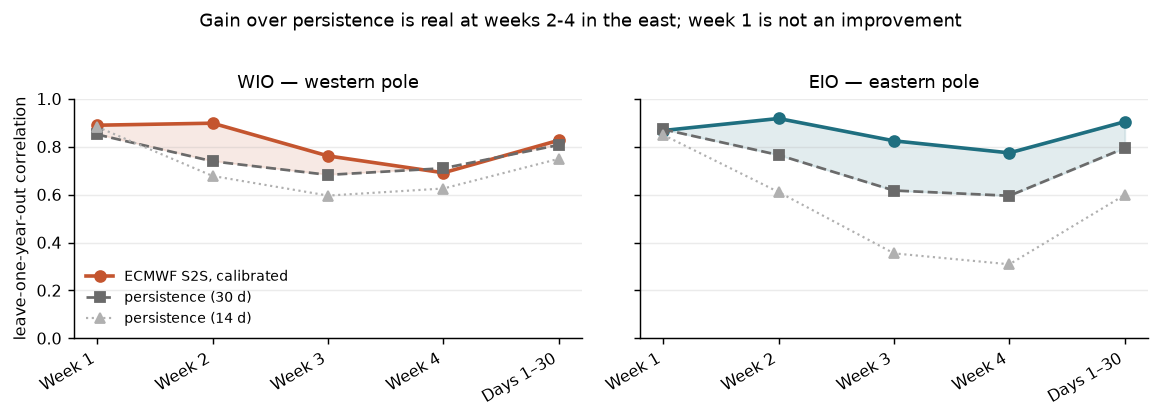

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.1), sharey=True)
xs = np.arange(len(iod.WINDOWS))
for ax, pole in zip(axes, iod.POLES):
    sp = skill.loc[pole.upper()]
    ax.plot(xs, sp["model_r"], "o-", color=POLE_C[pole], lw=2, label="ECMWF S2S, calibrated")
    ax.plot(xs, sp["persist30_r"], "s--", color="#6a6a6a", lw=1.5, label="persistence (30 d)")
    ax.plot(xs, sp["persist14_r"], "^:", color="#b0b0b0", lw=1.2, label="persistence (14 d)")
    ax.fill_between(xs, sp["persist30_r"], sp["model_r"],
                    where=(sp["model_r"] >= sp["persist30_r"]),
                    color=POLE_C[pole], alpha=.13, interpolate=True)
    ax.set_xticks(xs); ax.set_xticklabels([WLAB[w] for w in iod.WINDOWS], rotation=30, ha="right")
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=.25)
    ax.set_title(f"{pole.upper()} — {'western' if pole=='wio' else 'eastern'} pole")
axes[0].set_ylabel("leave-one-year-out correlation")
axes[0].legend(frameon=False, fontsize=7.5, loc="lower left")
fig.suptitle("Gain over persistence is real at weeks 2-4 in the east; week 1 is not an improvement",
             fontsize=10, y=1.02)
fig.tight_layout(); plt.show()

## The dipole, calibrated and raw

An earlier version of this notebook reported the dipole against "two
climatologies". That was wrong, and worth stating rather than quietly fixing:
least squares with an intercept is mean-preserving, so
`calibrated − obs_clim ≡ slope × (x₀ − x̄)` — the observed climatology
**cancels identically**, and setting both slopes to 1 recovers the other
column exactly.

So these are the **calibrated forecast** and the **uncalibrated model**. The gap
between them is the regression's *amplitude* correction: it stretches the west
(slope > 1, the ensemble mean under-disperses that pole) and shrinks the east
(slope < 1, where the model over-amplifies variability). Constant bias cancels
on both sides and is not what the difference shows.

In [6]:
print(res["dmi"].round(3).to_string())

         dmi_calibrated  dmi_raw   ci80  pole_resid_corr
window                                                  
week1             0.432    0.329  0.501           -0.409
week2             0.820    0.509  0.403           -0.239
week3             0.860    0.474  0.624           -0.050
week4             0.732    0.637  0.592            0.211
day1_30           0.725    0.506  0.424           -0.023


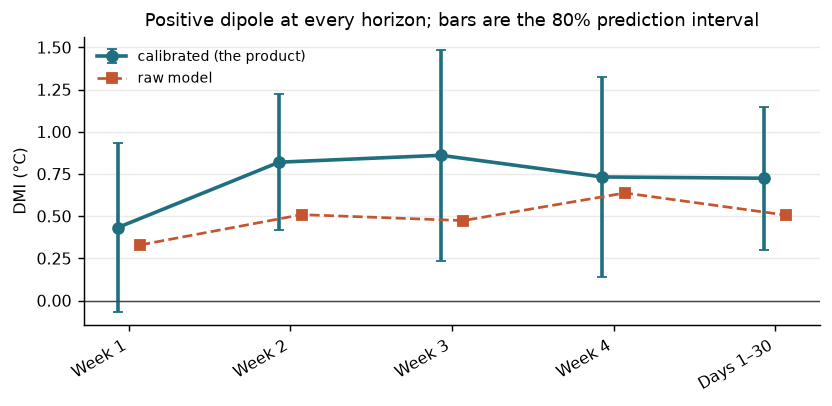

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
x = np.arange(len(iod.WINDOWS))
d = res["dmi"]
ax.errorbar(x - .07, d["dmi_calibrated"], yerr=d["ci80"], fmt="o-",
            color="#1f6f80", lw=2, capsize=3, label="calibrated (the product)")
ax.errorbar(x + .07, d["dmi_raw"], fmt="s--", color="#c4552f", lw=1.5,
            label="raw model")
ax.axhline(0, color="#444", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([WLAB[w] for w in iod.WINDOWS], rotation=30, ha="right")
ax.set_ylabel("DMI (°C)"); ax.grid(axis="y", alpha=.25)
ax.legend(frameon=False, fontsize=8)
ax.set_title("Positive dipole at every horizon; bars are the 80% prediction interval", fontsize=10)
fig.tight_layout(); plt.show()

## Calibrated SST fields

The box-mean slope cannot be reused per grid cell — the model's bias is not
spatially uniform, which is the entire reason for calibrating a field rather
than scaling one number. So every cell gets its own regression across the 20
reforecast years. OISST is block-averaged from 0.25° to the model's 1.5° first,
so each model cell is compared against the mean of the ocean it actually covers
rather than a single point sample.

Cells where the leave-one-year-out correlation falls below 0.4 are greyed:
at week 4 a substantial part of the basin is not skilfully predicted, and a map
that hides that would overstate the product.

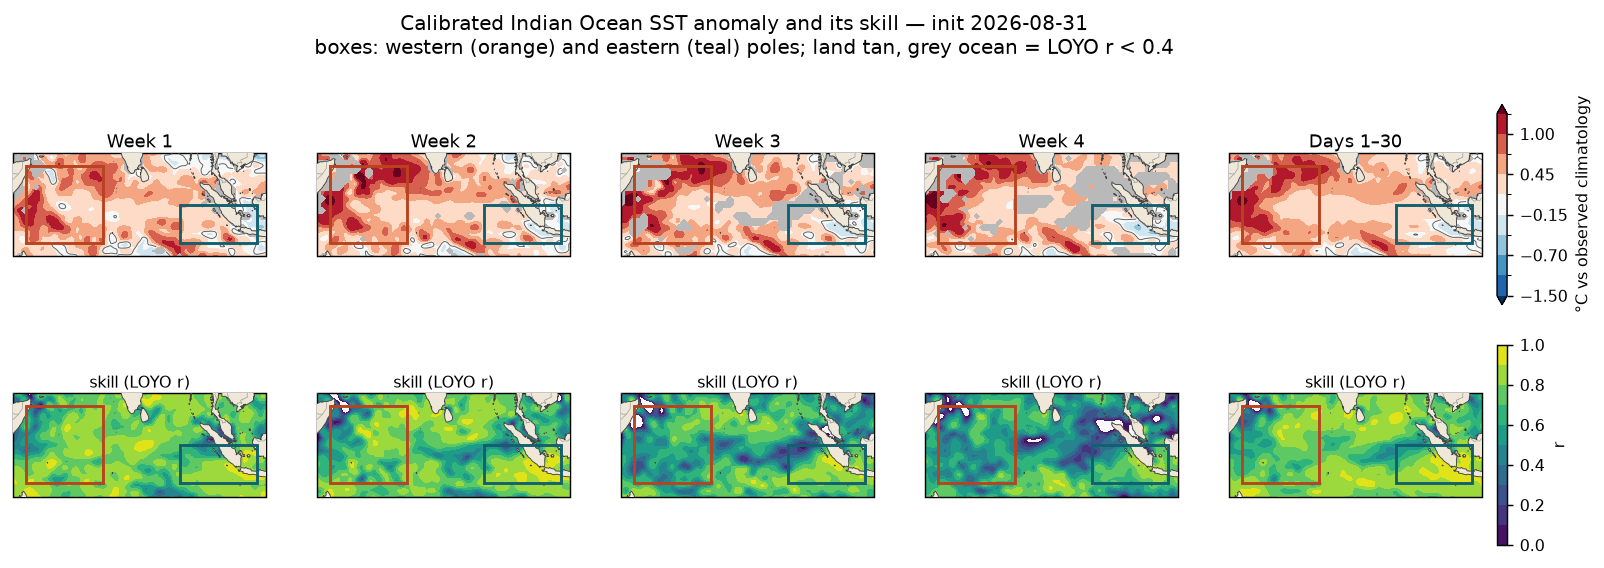

In [8]:
import cartopy.crs as ccrs
import make_maps as mm

# Same filled-contour renderer the report uses -- the GHACOF house style: cubic
# refinement onto a finer grid so the field reads as a field rather than as a
# mosaic of 1.5 deg model cells. Presentational only; every number quoted above
# comes from the native-resolution field.
cf = res["calibrated_fields"]
anom = cf.calibrated_sst - cf.obs_climatology
proj = ccrs.PlateCarree()
norm = mm.BoundaryNorm(mm.LEVELS, ncolors=plt.get_cmap("RdBu_r").N, extend="both")

fig, axes = plt.subplots(2, 5, figsize=(15, 4.4), subplot_kw={"projection": proj})
for j, w in enumerate(iod.WINDOWS):
    cs = mm._panel(axes[0, j], anom.sel(window=w),
                   cf.loyo_r.sel(window=w) >= mm.SKILL_FLOOR, proj, norm, WLAB[w])
    # the skill field itself, on the same refined basemap
    sfine = mm.refine(cf.loyo_r.sel(window=w))
    sk = axes[1, j].contourf(sfine["lon"].values, sfine["lat"].values, sfine.values,
                             levels=np.arange(0, 1.01, 0.1), cmap="viridis",
                             transform=proj, zorder=2, extend="neither")
    mm._basemap(axes[1, j], proj)
    axes[1, j].set_title("skill (LOYO r)", fontsize=9, pad=3)
fig.colorbar(cs, ax=axes[0, :].tolist(), fraction=.018, pad=.01,
             ticks=mm.LEVELS[::2], label="°C vs observed climatology")
fig.colorbar(sk, ax=axes[1, :].tolist(), fraction=.018, pad=.01, label="r")
fig.suptitle(f"Calibrated Indian Ocean SST anomaly and its skill — init {INIT}\n"
             "boxes: western (orange) and eastern (teal) poles; land tan, grey ocean = LOYO r < 0.4",
             fontsize=11, y=1.04)
plt.show()

## Output

One row per index and horizon, with the calibrated value, its anomaly against
the observed climatology, an 80% interval from the regression residuals, and the
honest skill numbers beside it.

In [9]:
rows = []
for pole in iod.POLES:
    t = res["poles"][pole]
    sk = skill.loc[pole.upper()]
    for w in iod.WINDOWS:
        vs, ve = iod.window_valid_dates(INIT, w)
        rows.append(dict(init=INIT, index=pole.upper(), window=w,
                         valid_from=vs.date(), valid_to=ve.date(),
                         calibrated_C=round(t.loc[w, "calibrated"], 3),
                         anomaly_C=round(t.loc[w, "calibrated"] - t.loc[w, "obs_clim"], 3),
                         ci80=round(t.loc[w, "ci80"], 3),
                         loyo_r=round(sk.loc[w, "model_r"], 3),
                         persist30_r=round(sk.loc[w, "persist30_r"], 3),
                         gain30=round(sk.loc[w, "gain30"], 3)))
out = pd.DataFrame(rows)
out.to_csv(f"outputs/indices_{INIT}.csv", index=False)
res["dmi"].reset_index().assign(init=INIT).to_csv(f"outputs/dmi_{INIT}.csv", index=False)
cf.to_netcdf(f"outputs/calibrated_fields_{INIT}.nc")
print(out.to_string(index=False))
print(f"\nwrote outputs/indices_{INIT}.csv, dmi_{INIT}.csv, calibrated_fields_{INIT}.nc")

      init index  window valid_from   valid_to  calibrated_C  anomaly_C  ci80  loyo_r  persist30_r  gain30
2026-08-31   WIO   week1 2026-08-31 2026-09-06        28.358      0.701 0.222   0.890        0.851   0.039
2026-08-31   WIO   week2 2026-09-07 2026-09-13        28.733      1.025 0.240   0.898        0.739   0.159
2026-08-31   WIO   week3 2026-09-14 2026-09-20        28.814      1.016 0.439   0.762        0.682   0.079
2026-08-31   WIO   week4 2026-09-21 2026-09-27        28.776      0.834 0.427   0.691        0.710  -0.019
2026-08-31   WIO day1_30 2026-08-31 2026-09-29        28.683      0.889 0.303   0.827        0.807   0.020
2026-08-31   EIO   week1 2026-08-31 2026-09-06        28.360      0.269 0.355   0.868        0.873  -0.005
2026-08-31   EIO   week2 2026-09-07 2026-09-13        28.314      0.205 0.262   0.918        0.765   0.152
2026-08-31   EIO   week3 2026-09-14 2026-09-20        28.263      0.155 0.415   0.825        0.617   0.207
2026-08-31   EIO   week4 2026-09-21 2

## Caveats

* **Week 1 adds nothing over persistence**, in either box at any baseline
  tested, and neither does the west at week 4. The value is weeks 2–4, in the
  east especially.
* **Near-term values run above independent estimates.** BoM has the IOD neutral
  (+0.25) for the week we forecast at +0.43; our own observations give +0.01.
  Direction over the season is not in dispute — a positive IOD is the consensus
  — but the near-term level should be read as an upper estimate.
* **The baseline is 2006–2025**, the reforecast period, not the 1991–2020
  climatology BoM/CPC/NOAA publish against. The anomalies are not directly
  comparable with theirs.
* **The interval is a prediction interval** on Student's t, carrying the
  leverage term — this forecast sits 2.3–3.0 sd beyond the training mean in the
  west, so the naive `1.28 × resid_sd` understated it by 20–28%.
* **The ensemble mean is calibrated, not the spread.** With 100 real-time
  members a spread-aware interval is reachable and would be the natural next step.
* **Twenty years is a short fit.** Every slope rests on 20 points; leave-one-year-out
  rather than in-sample skill is quoted throughout for that reason.
* **Field and index calibration disagree slightly** (0.1–0.3 °C on WIO). Fitting
  per cell then area-averaging is not the same operation as fitting the
  area-average. The index table is the number to quote for an index.